# UGS Withdrawal Curve — Fill Level vs. Maximum Withdrawal Capacity

**Purpose**  
Infer the relationship between Czech UGS fill level and the maximum achievable
gas withdrawal rate (the "withdrawal curve").  This curve is a key input for
storage sizing: it determines how fast gas can be drawn from storage at each
fill level during a cold-winter stress event.

**Method**  
The GIE dataset reports two withdrawal columns:

| Column | What it represents |
|---|---|
| `Withdrawal (GWh/d)` | Actual daily withdrawal — what was physically taken out |
| `Withdrawal capacity (GWh/d)` | Declared technical capacity — a step-changing infrastructure metric |

The declared capacity is not fill-dependent; it has grown monotonically from
~428 GWh/d (2011–13) to ~734 GWh/d (2026) as new caverns came online.

The withdrawal curve is inferred from **observed withdrawals as a function of
fill level**, using two complementary approaches for robustness:

- **Absolute**: P95 of raw `Withdrawal (GWh/d)` per fill-level bin — directly
  readable, but mixes infrastructure vintages.
- **Relative**: P95 of the utilisation ratio `Withdrawal / Withdrawal capacity`
  per fill-level bin, then scaled by today's declared capacity — normalises
  out the capacity growth.

P95 is chosen over p95 because observed withdrawals are demand-limited on most
days, so the true physical capacity is systematically understated.  P99 was
rejected because with only 15–32 observations in the low-fill bins it is
statistically indistinguishable from the single-day maximum.

**Data window**: winter months only (Oct–Mar), post-March 2022 only, to match
the structural break used in the import analysis.

---
## 0. Setup

In [ ]:
# Set CWD to root so there is no need to install the bsd package (will work with conda)

import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import bsd.constants as bconst
import bsd.data as bdata
import bsd.withdrawal as bwc
import bsd.jvs as jvs
from bsd.constants import FIGS_DIR

jvs.apply_style(theme="light", context="notebook")

%matplotlib inline

STORAGE_FILE = bdata.DATA_PATH_STORAGE_GIE
CUTOFF       = pd.Timestamp(bdata.DEFAULT_CUTOFF)

# Bin parameters — shared with the production library via bsd.constants
BIN_EDGES  = np.array(bconst.WC_BIN_EDGES, dtype=float)
BIN_LABELS = (BIN_EDGES[:-1] + 2.5).astype(float)
QUANTILE   = bconst.WC_BIN_QUANTILE
MIN_OBS    = bconst.WC_MIN_OBS

---
## 1. Load and clean GIE storage data

In [10]:
# Full dataset overview (no cutoff) — summary statistics only
sto_all = bdata.load_storage_gie(STORAGE_FILE, cutoff=None)
print(
    f"Full dataset: {len(sto_all):,} rows  ({sto_all.date.min().date()} → {sto_all.date.max().date()})"
)
print(f"Fill %:  {sto_all.fill_pct.min():.1f} – {sto_all.fill_pct.max():.1f}")
print(
    f"WC declared: {sto_all.wc_declared.min():.0f} – {sto_all.wc_declared.max():.0f} GWh/d"
)

Full dataset: 5,627 rows  (2011-01-01 → 2026-05-28)
Fill %:  12.2 – 101.5
WC declared: 426 – 736 GWh/d


In [11]:
# Post-cutoff winter data for analysis
sto = bdata.load_storage_gie(STORAGE_FILE, cutoff=CUTOFF)
sto["month"] = sto["date"].dt.month
winter = sto[sto["month"].isin(bdata.WINTER_MONTHS)].copy()

# Utilisation ratio (0–1): how much of declared capacity was actually used
winter["util_ratio"] = winter["withdrawal"] / winter["wc_declared"]

# Current declared capacity — use most recent value as the scaling anchor
WC_CURRENT = winter.loc[winter["date"] == winter["date"].max(), "wc_declared"].iloc[0]

print(
    f"Analysis window: {len(winter):,} winter days  ({winter.date.min().date()} → {winter.date.max().date()})"
)
print(f"Months: {sorted(winter.month.unique())}")
print(f"Current declared WC: {WC_CURRENT:.1f} GWh/d")
print(f"\nActual withdrawal stats (GWh/d):")
print(winter["withdrawal"].describe().round(1))

Analysis window: 729 winter days  (2022-10-01 → 2026-03-31)
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(10), np.int32(11), np.int32(12)]
Current declared WC: 732.1 GWh/d

Actual withdrawal stats (GWh/d):
count    729.0
mean     144.6
std      112.1
min        0.0
25%       51.9
50%      120.9
75%      218.0
max      453.9
Name: withdrawal, dtype: float64


---
## 2. Scatter — observed withdrawals vs. fill level

Before fitting, look at the raw data to understand the identification problem:
most days operators draw far less than storage can deliver (demand-limited, not
supply-limited).  The upper envelope is the signal we want.

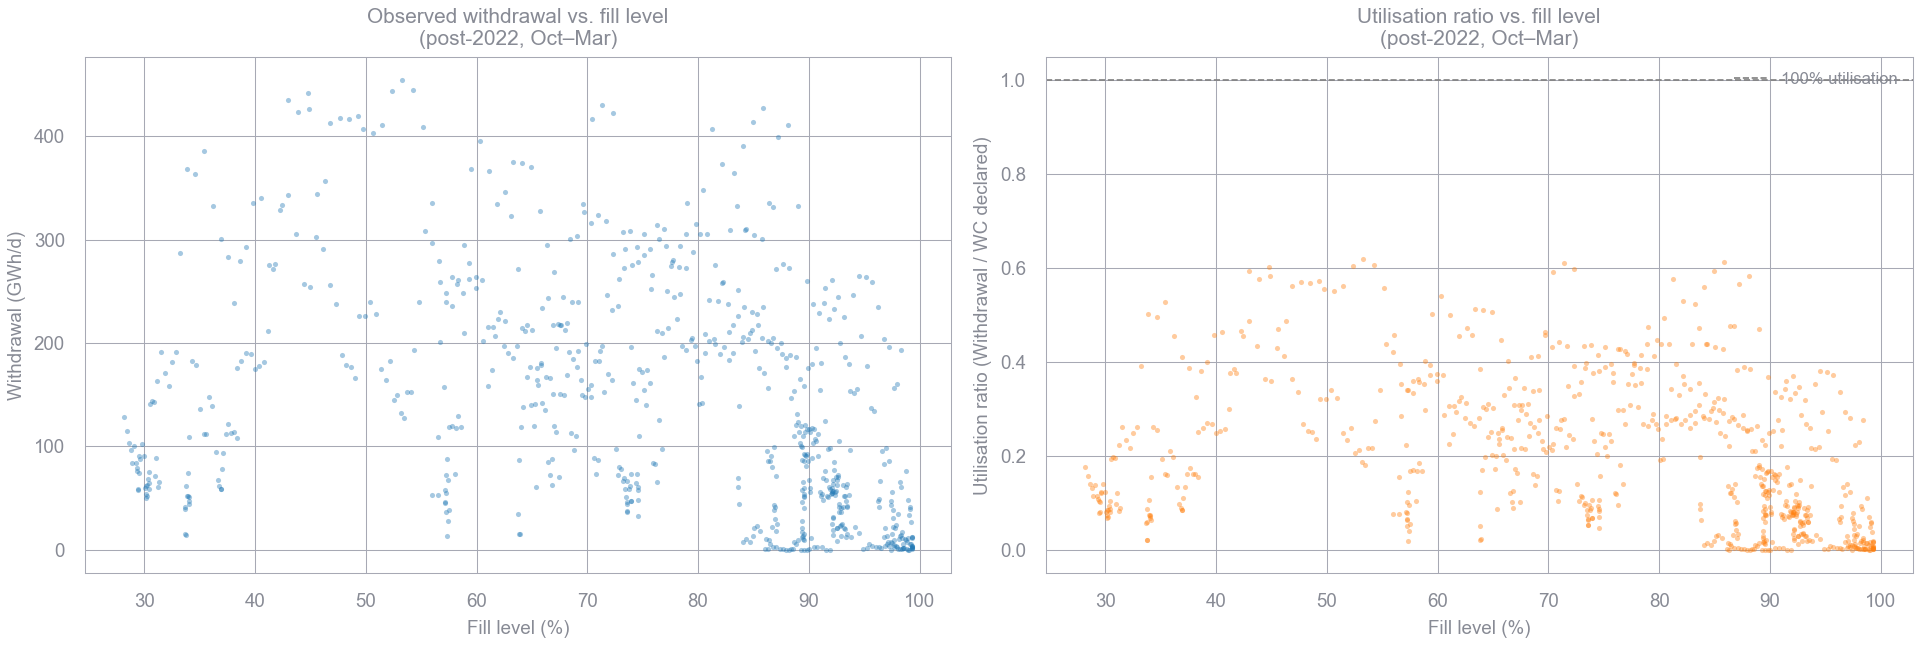

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── left: absolute withdrawal ────────────────────────────────────────────
ax = axes[0]
ax.scatter(winter["fill_pct"], winter["withdrawal"],
           s=6, alpha=0.4, color="#1f77b4", linewidths=0)
ax.set_xlabel("Fill level (%)")
ax.set_ylabel("Withdrawal (GWh/d)")
ax.set_title("Observed withdrawal vs. fill level\n(post-2022, Oct–Mar)")
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# ── right: utilisation ratio ─────────────────────────────────────────────
ax = axes[1]
ax.scatter(winter["fill_pct"], winter["util_ratio"],
           s=6, alpha=0.4, color="#ff7f0e", linewidths=0)
ax.set_xlabel("Fill level (%)")
ax.set_ylabel("Utilisation ratio (Withdrawal / WC declared)")
ax.set_title("Utilisation ratio vs. fill level\n(post-2022, Oct–Mar)")
ax.axhline(1.0, color="grey", lw=0.8, ls="--", label="100% utilisation")
ax.legend(fontsize=8)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

fig.tight_layout()
fig.savefig(FIGS_DIR / "withdrawal_scatter.png", bbox_inches="tight")
fig;

---
## 3. Binned P95 upper envelope

Assign each day to a 5 pp fill-level bin, compute the P95 of withdrawals in
that bin, and count the sample size.  Bins with fewer than 5 observations are
flagged as unreliable. There are no such bins.

In [24]:
winter["fill_bin"] = pd.cut(
    winter["fill_pct"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
).astype(float)

bins = (
    winter.groupby("fill_bin", observed=False)
    .agg(
        n          = ("withdrawal",  "count"),
        p95_abs    = ("withdrawal",  lambda x: x.quantile(QUANTILE)),
        p95_ratio  = ("util_ratio",  lambda x: x.quantile(QUANTILE)),
    )
    .reset_index()
    .rename(columns={"fill_bin": "fill_mid"})
)

# Relative approach: scale P95 ratio by current declared capacity
bins["p95_rel"] = bins["p95_ratio"] * WC_CURRENT

bins["reliable"] = bins["n"] >= MIN_OBS

print(f"Bins with ≥{MIN_OBS} obs: {bins['reliable'].sum()} / {len(bins)}")
bins[["fill_mid", "n", "p95_abs", "p95_rel", "p95_ratio", "reliable"]].round(1)

Bins with ≥5 obs: 15 / 15


,fill_mid,n,p95_abs,p95_rel,p95_ratio,reliable
0,27.5,16,118.6,118.6,0.2,True
1,32.5,40,291.0,291.0,0.4,True
2,37.5,29,334.4,334.4,0.5,True
3,42.5,18,436.3,436.3,0.6,True
4,47.5,17,418.3,418.3,0.6,True
5,52.5,18,446.1,446.1,0.6,True
6,57.5,42,333.8,334.4,0.5,True
7,62.5,36,374.7,374.7,0.5,True
8,67.5,53,312.5,312.9,0.4,True
9,72.5,61,323.9,323.9,0.4,True


---
## 4. Monotone curve fitting (isotonic regression)

Gas withdrawal capacity is physically monotone increasing in fill level (higher
reservoir pressure → higher deliverability), so we enforce monotonicity via
isotonic regression.  We fit separately on absolute and relative P95 envelopes,
using only reliable bins as anchor points.

In [25]:
# Fit production withdrawal curves via the library.
# Note: fit_withdrawal_curves() does not expose per-bin fitted values in the bins
# DataFrame; the chart (Section 5) evaluates the library callables directly.
curves = bwc.fit_withdrawal_curves(gie_path=STORAGE_FILE, cutoff=CUTOFF)

print("Fitted curve at selected fill levels (GWh/d):")
check_fills = [20, 30, 40, 50, 60, 70, 80, 90]
for f in check_fills:
    abs_v = float(curves.empirical_abs(f))
    rel_v = float(curves.empirical(f))
    print(f"  {f:3d}%  absolute={abs_v:6.1f}  relative={rel_v:6.1f}  diff={abs_v-rel_v:+.1f}")

Fitted curve at selected fill levels (GWh/d):
   20%  absolute= 118.6  relative= 118.6  diff=+0.0
   30%  absolute= 204.8  relative= 204.8  diff=+0.0
   40%  absolute= 337.9  relative= 340.4  diff=-2.5
   50%  absolute= 341.4  relative= 346.4  diff=-5.0
   60%  absolute= 341.4  relative= 346.4  diff=-5.0
   70%  absolute= 341.4  relative= 346.4  diff=-5.0
   80%  absolute= 341.4  relative= 346.4  diff=-5.0
   90%  absolute= 341.4  relative= 346.4  diff=-5.0


---
## 5. Comparison chart — absolute vs. relative curves

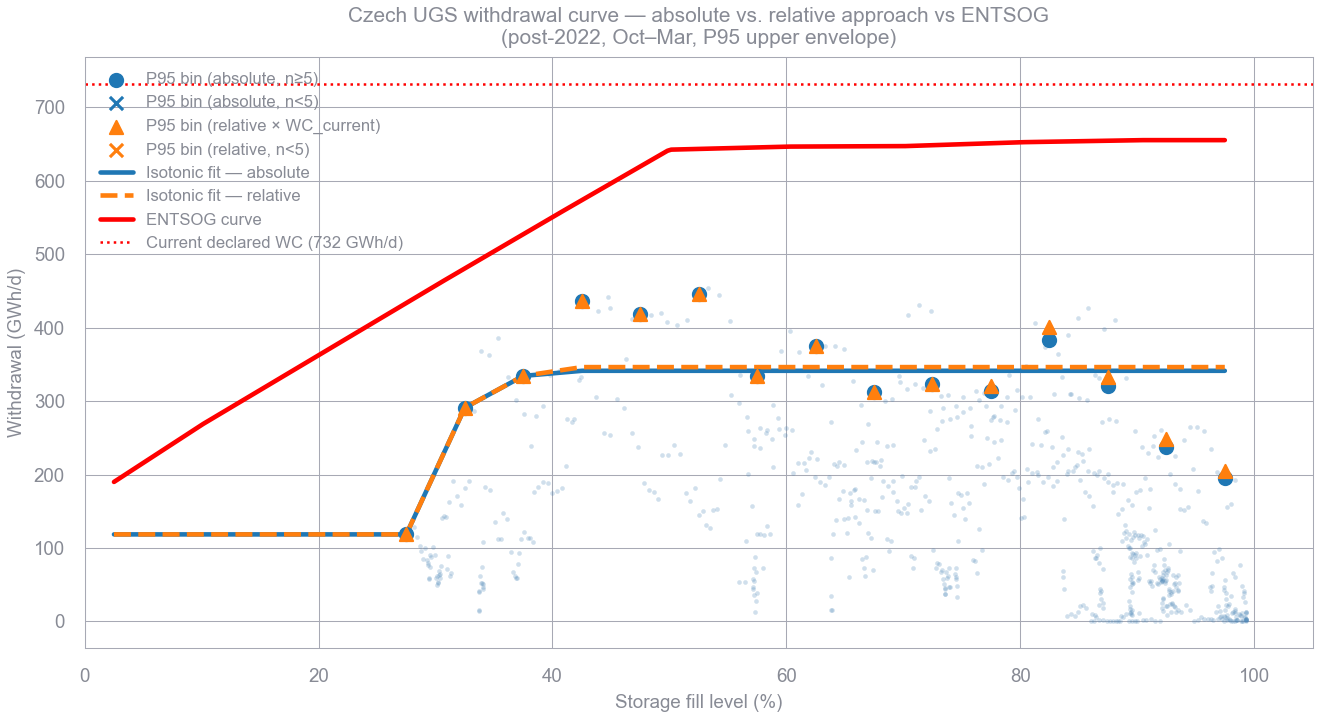

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

# Dense fill-level grid for smooth curve evaluation
fill_x = np.linspace(2.5, 97.5, 300)

# Raw scatter (faint background)
ax.scatter(winter["fill_pct"], winter["withdrawal"],
           s=5, alpha=0.25, color="steelblue", linewidths=0, label="_nolegend_")

# P95 bin markers — reliable vs. unreliable
rel_bins   = bins[bins["reliable"]]
unrel_bins = bins[~bins["reliable"]]

ax.scatter(rel_bins["fill_mid"],   rel_bins["p95_abs"],
           s=40, color="#1f77b4", zorder=4, label=f"P{int(QUANTILE*100)} bin (absolute, n≥{MIN_OBS})")
ax.scatter(unrel_bins["fill_mid"], unrel_bins["p95_abs"],
           s=40, color="#1f77b4", marker="x", zorder=4, label=f"P{int(QUANTILE*100)} bin (absolute, n<{MIN_OBS})")

ax.scatter(rel_bins["fill_mid"],   rel_bins["p95_rel"],
           s=40, color="#ff7f0e", marker="^", zorder=4, label=f"P{int(QUANTILE*100)} bin (relative × WC_current)")
ax.scatter(unrel_bins["fill_mid"], unrel_bins["p95_rel"],
           s=40, color="#ff7f0e", marker="x", zorder=4, label=f"P{int(QUANTILE*100)} bin (relative, n<{MIN_OBS})")

# Fitted curves — evaluated from library callables (interp1d linear), matching production
ax.plot(fill_x, np.vectorize(curves.empirical_abs)(fill_x),
        lw=2.2, color="#1f77b4", label="Isotonic fit — absolute")
ax.plot(fill_x, np.vectorize(curves.empirical)(fill_x),
        lw=2.2, color="#ff7f0e", ls="--", label="Isotonic fit — relative")
ax.plot(fill_x, np.vectorize(curves.engineering)(fill_x),
        lw=2.2, color="red", label="ENTSOG curve")


# Declared capacity reference line
ax.axhline(WC_CURRENT, color="red", lw=1.2, ls=":", label=f"Current declared WC ({WC_CURRENT:.0f} GWh/d)")

ax.set_xlabel("Storage fill level (%)")
ax.set_ylabel("Withdrawal (GWh/d)")
ax.set_title("Czech UGS withdrawal curve — absolute vs. relative approach vs ENTSOG\n"
             f"(post-{CUTOFF.year}, Oct–Mar, P{int(QUANTILE*100)} upper envelope)")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, 105)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

fig.tight_layout()
fig.savefig(FIGS_DIR / "withdrawal_curve.png", bbox_inches="tight")
fig;

---
## 6. Final withdrawal curve table

Export the curve as a lookup table for use in downstream storage sizing.
Two columns are provided — use `wc_abs` if you want to anchor to historical
observed levels; use `wc_rel` if you want to normalise out infrastructure
growth and project onto current declared capacity.

In [16]:
# Display table: evaluate library curves at bin midpoints
curve = bins[["fill_mid", "n", "reliable"]].copy()
curve["wc_abs_GWh_d"] = np.vectorize(curves.empirical_abs)(curve["fill_mid"].values)
curve["wc_rel_GWh_d"] = np.vectorize(curves.empirical)(curve["fill_mid"].values)
curve.columns = ["fill_pct", "n_obs", "reliable", "wc_abs_GWh_d", "wc_rel_GWh_d"]

# Library callables for downstream use — interp1d linear, matching the production simulation
wc_curve_abs = curves.empirical_abs
wc_curve_rel = curves.empirical

print(f"wc_curve_abs(fill_pct) and wc_curve_rel(fill_pct) are callable interpolators.\n")
curve.round(1)

wc_curve_abs(fill_pct) and wc_curve_rel(fill_pct) are callable interpolators.



,fill_pct,n_obs,reliable,wc_abs_GWh_d,wc_rel_GWh_d
0,27.5,16,True,118.6,118.6
1,32.5,40,True,291.0,291.0
2,37.5,29,True,334.4,334.4
3,42.5,18,True,341.4,346.4
4,47.5,17,True,341.4,346.4
5,52.5,18,True,341.4,346.4
6,57.5,42,True,341.4,346.4
7,62.5,36,True,341.4,346.4
8,67.5,53,True,341.4,346.4
9,72.5,61,True,341.4,346.4


---
## 7. Notes and caveats

**Identification problem**  
Observed withdrawals are demand-limited on most winter days: operators take
what they need, not what storage can deliver.  The P95 upper envelope traces
the capacity curve only where demand happened to stress storage near its
physical limit.  This means:
- The curve is likely an *underestimate* at low fill levels (few high-demand
  days occur when storage is already depleted).
- Bins below ~20% fill should be treated with extra caution.

**Why P95, not P90 or P99**  
P95 picks up materially more stressed days than P90 (e.g. at the 32.5% bin:
P90 = 191 GWh/d, P95 = 291 GWh/d), reflecting a genuine cluster of high-demand
days rather than noise.  P99 was rejected because with only 15–32 observations
in the low-fill bins it is statistically indistinguishable from the single-day
maximum and therefore too sensitive to outliers.

**Absolute vs. relative**  
If the two curves agree closely, the result is robust to infrastructure growth
normalisation.  If they diverge, the relative curve is preferable for
forward-looking use because it correctly accounts for the capacity expansions
since 2022.

**Winter definition**  
October is included (aligned with `WINTER_MONTHS`).  October fill levels tend
to be high (>60%), so they constrain the upper end of the curve well but add
little information about low-fill behaviour.

**Next step**  
Use `wc_curve_rel(fill_pct)` (or `wc_curve_abs`) as the withdrawal capacity
input in the storage sizing model: at any point in the draw-down simulation,
the maximum daily withdrawal rate is `wc_curve(current_fill_pct)`.